General purpose models were tested here and then fine-tuned later on

# PekingU/rtdetr
https://huggingface.co/PekingU/rtdetr_r101vd_coco_o365

In [ ]:
!pip install torch pillow transformers pycocotools datasets torchvision

In [ ]:
# Obtain COCO data
!wget http://images.cocodataset.org/zips/val2017.zip
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip

!unzip /content/val2017.zip -d /content/coco_images
!unzip /content/annotations_trainval2017.zip

Streaming output truncated to the last 5000 lines.
 extracting: /content/coco_images/val2017/000000320425.jpg  
 extracting: /content/coco_images/val2017/000000481404.jpg  
 extracting: /content/coco_images/val2017/000000314294.jpg  
 extracting: /content/coco_images/val2017/000000335328.jpg  
 extracting: /content/coco_images/val2017/000000513688.jpg  
 extracting: /content/coco_images/val2017/000000158548.jpg  
 extracting: /content/coco_images/val2017/000000132116.jpg  
 extracting: /content/coco_images/val2017/000000415238.jpg  
 extracting: /content/coco_images/val2017/000000321333.jpg  
 extracting: /content/coco_images/val2017/000000081738.jpg  
 extracting: /content/coco_images/val2017/000000577584.jpg  
 extracting: /content/coco_images/val2017/000000346905.jpg  
 extracting: /content/coco_images/val2017/000000433980.jpg  
 extracting: /content/coco_images/val2017/000000228144.jpg  
 extracting: /content/coco_images/val2017/000000041872.jpg  
 extracting: /content/coco_images/

In [ ]:
from pycocotools.coco import COCO
import numpy as np
import torch
import requests
from PIL import Image
from transformers import RTDetrForObjectDetection, RTDetrImageProcessor

coco_gt = COCO('/content/annotations/instances_val2017.json')

# Convert from pixels to bounding widht and height
def xyxy_to_xywh(box):
    x1, y1, x2, y2 = box
    return [x1, y1, x2 - x1, y2 - y1]

ann_ids = coco_gt.getAnnIds()
annotations = coco_gt.loadAnns(ann_ids)
cat_ids = [ann["category_id"] for ann in annotations]
categories = coco_gt.loadCats(cat_ids)
name_to_id = {cat['name']: cat['id'] for cat in categories}

loading annotations into memory...
Done (t=0.94s)
creating index...
index created!


In [ ]:
img_ids = coco_gt.getImgIds()

img_ids = img_ids

In [ ]:
# test Peking model
peking_model_results = []

for id in img_ids:
  # Select image
  imgIds = coco_gt.getImgIds(imgIds = [id])
  img = coco_gt.loadImgs(imgIds[np.random.randint(0,len(imgIds))])[0]

  url = img['coco_url']
  image = Image.open(requests.get(url, stream=True).raw).convert("RGB") # Added .convert("RGB")

  image_processor = RTDetrImageProcessor.from_pretrained("PekingU/rtdetr_r101vd_coco_o365")
  model = RTDetrForObjectDetection.from_pretrained("PekingU/rtdetr_r101vd_coco_o365")

  inputs = image_processor(images=image, return_tensors="pt")

  with torch.no_grad():
    outputs = model(**inputs)

  results = image_processor.post_process_object_detection(outputs, target_sizes=torch.tensor([image.size[::-1]]), threshold=0.3)

  output = []

  for result in results:
    for score, label_id, box in zip(result["scores"], result["labels"], result["boxes"]):
        score, label = score.item(), label_id.item()
        box = xyxy_to_xywh([round(i, 2) for i in box.tolist()])

        if model.config.id2label[label] in name_to_id:
          peking_model_results.append({
              "image_id": img['id'],
              "category_id": name_to_id[model.config.id2label[label]],
              "bbox": box,
              "score": score
            })

In [ ]:
# Save results in json file
import json

with open('/content/peking_model_results.json', 'w') as json_file:
  json.dump(peking_model_results, json_file, indent=4)

NameError: name 'peking_model_results' is not defined

## DFINE small

In [ ]:
# Test DFINE small
from transformers import DFineForObjectDetection, AutoImageProcessor

dfine_small_model_results = []

for id in img_ids:
  imgIds = coco_gt.getImgIds(imgIds = [id])
  img = coco_gt.loadImgs(imgIds[np.random.randint(0,len(imgIds))])[0]

  url = img['coco_url']
  image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

  image_processor = AutoImageProcessor.from_pretrained("ustc-community/dfine-small-coco")
  model = DFineForObjectDetection.from_pretrained("ustc-community/dfine-small-coco")

  inputs = image_processor(images=image, return_tensors="pt")

  with torch.no_grad():
    outputs = model(**inputs)

  results = image_processor.post_process_object_detection(outputs, target_sizes=torch.tensor([image.size[::-1]]), threshold=0.3)

  for result in results:
      for score, label_id, box in zip(result["scores"], result["labels"], result["boxes"]):
        score, label = score.item(), label_id.item()
        box = xyxy_to_xywh([round(i, 2) for i in box.tolist()])

        if model.config.id2label[label] in name_to_id:
          dfine_small_model_results.append({
              "image_id": img['id'],
              "category_id": name_to_id[model.config.id2label[label]],
              "bbox": box,
              "score": score
            })

In [ ]:
import json

with open('/content/dfine_small_results.json', 'w') as json_file:
  json.dump(dfine_small_model_results, json_file, indent=4)

Loading and preparing results...
DONE (t=0.63s)
creating index...
index created!


## DFINE medium

In [ ]:
# Test DFINE medium
from transformers import DFineForObjectDetection, AutoImageProcessor

dfine_medium_model_results = []

for index, id in enumerate(img_ids):
  imgIds = coco_gt.getImgIds(imgIds = [id])
  img = coco_gt.loadImgs(imgIds[np.random.randint(0,len(imgIds))])[0]

  url = img['coco_url']
  image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

  image_processor = AutoImageProcessor.from_pretrained("ustc-community/dfine-medium-coco")
  model = DFineForObjectDetection.from_pretrained("ustc-community/dfine-medium-coco")
  inputs = image_processor(images=image, return_tensors="pt")

  with torch.no_grad():
    outputs = model(**inputs)

  results = image_processor.post_process_object_detection(outputs, target_sizes=torch.tensor([image.size[::-1]]), threshold=0.3)

  for result in results:
      for score, label_id, box in zip(result["scores"], result["labels"], result["boxes"]):
        score, label = score.item(), label_id.item()
        box = xyxy_to_xywh([round(i, 2) for i in box.tolist()])

        if model.config.id2label[label] in name_to_id:
          dfine_medium_model_results.append({
              "image_id": img['id'],
              "category_id": name_to_id[model.config.id2label[label]],
              "bbox": box,
              "score": score
            })

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 97c116c9-c0fe-4f8d-b037-30fcb8233eeb)')' thrown while requesting HEAD https://huggingface.co/ustc-community/dfine-medium-coco/resolve/main/processor_config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 1df1fc68-7d35-4978-8670-12d6a7ea7662)')' thrown while requesting HEAD https://huggingface.co/ustc-community/dfine-medium-coco/resolve/main/processor_config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: f67234ce-cb32-4678-afc4-1aa69402825f)')' thrown while requesting HEAD https://huggingface.co/ustc-community/dfine-medium-coco/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=

KeyboardInterrupt: 

In [ ]:
import json

with open('/content/dfine_medium_results.json', 'w') as json_file:
  json.dump(dfine_medium_model_results, json_file, indent=4)

# Yolos model

In [ ]:
# Test Yolos
from transformers import YolosFeatureExtractor, YolosForObjectDetection

yolos_small_model_results = []

ids = []

for id in img_ids:
  imgIds = coco_gt.getImgIds(imgIds = [id])
  img = coco_gt.loadImgs(imgIds[np.random.randint(0,len(imgIds))])[0]

  url = img['coco_url']
  image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

  feature_extractor = YolosFeatureExtractor.from_pretrained('hustvl/yolos-small')
  model = YolosForObjectDetection.from_pretrained('hustvl/yolos-small')

  inputs = feature_extractor(images=image, return_tensors="pt")
  outputs = model(**inputs)

  target_sizes = torch.tensor([image.size[::-1]])
  results = feature_extractor.post_process_object_detection(outputs, threshold=0.9, target_sizes=target_sizes)[0]

  for score, label_id, box in zip(results["scores"], results["labels"], results["boxes"]):
    score, label = score.item(), label_id.item()
    box = xyxy_to_xywh([round(i, 2) for i in box.tolist()])

    if model.config.id2label[label] in name_to_id:
      yolos_small_model_results.append({
          "image_id": img['id'],
          "category_id": name_to_id[model.config.id2label[label]],
          "bbox": box,
          "score": score
        })
  ids.append(id)

KeyboardInterrupt: 

In [ ]:
import json

with open('yolos_small_model_results.json', 'w') as json_file:
  json.dump(yolos_small_model_results, json_file, indent=4)

# Faster RNN
 implementation using Feature Pyramid Networks and ResNet50 backbone

In [ ]:
!pip install -q torch torchvision pycocotools pillow

In [ ]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
model.to(device)
model.eval()

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:08<00:00, 20.5MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
COCO_CATEGORIES = [
    "__background__", "person", "bicycle", "car", "motorcycle", "airplane",
    "bus", "train", "truck", "boat", "traffic light", "fire hydrant",
    "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse",
    "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack",
    "umbrella", "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard",
    "sports ball", "kite", "baseball bat", "baseball glove", "skateboard",
    "surfboard", "tennis racket", "bottle", "wine glass", "cup", "fork",
    "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange",
    "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair",
    "couch", "potted plant", "bed", "dining table", "toilet", "tv", "laptop",
    "mouse", "remote", "keyboard", "cell phone", "microwave", "oven",
    "toaster", "sink", "refrigerator", "book", "clock", "vase", "scissors",
    "teddy bear", "hair drier", "toothbrush"
]

In [ ]:
from PIL import Image
import torchvision.transforms as T
import requests

faster_rnn_model_results = []

for id in img_ids:
  imgIds = coco_gt.getImgIds(imgIds = [id])
  img = coco_gt.loadImgs(imgIds[np.random.randint(0,len(imgIds))])[0]

  url = img['coco_url']
  image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

  transform = T.Compose([T.ToTensor()])
  img_tensor = transform(image).to(device)

  with torch.no_grad():
    outputs = model([img_tensor])

  results = outputs[0]

  for score, label_id, box in zip(results["scores"], results["labels"], results["boxes"]):
    score, label = score.item(), label_id.item()
    box = xyxy_to_xywh([round(i, 2) for i in box.tolist()])

    if label < len(COCO_CATEGORIES):
      class_name = COCO_CATEGORIES[label]
      faster_rnn_model_results.append({
          "image_id": img['id'],
          "category_id": name_to_id[class_name],
          "bbox": box,
          "score": score
        })

In [ ]:
import json

with open('faster_rnn_results.json', 'w') as json_file:
  json.dump(faster_rnn_model_results, json_file, indent=4)

Loading and preparing results...
DONE (t=0.19s)
creating index...
index created!


# Mask rnn

In [ ]:
import torch
from torchvision.models.detection import maskrcnn_resnet50_fpn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = maskrcnn_resnet50_fpn(weights="DEFAULT")
model.to(device)
model.eval()

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:10<00:00, 17.1MB/s]


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [ ]:
from PIL import Image
import torchvision.transforms as T
import requests

mask_rnn_model_results = []

for id in img_ids:
  imgIds = coco_gt.getImgIds(imgIds = [id])
  img = coco_gt.loadImgs(imgIds[np.random.randint(0,len(imgIds))])[0]

  url = img['coco_url']
  image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

  transform = T.Compose([T.ToTensor()])
  img_tensor = transform(image).to(device)

  with torch.no_grad():
    outputs = model([img_tensor])

  results = outputs[0]

  for score, label_id, box in zip(results["scores"], results["labels"], results["boxes"]):
    score, label = score.item(), label_id.item()
    box = xyxy_to_xywh([round(i, 2) for i in box.tolist()])

    if label < len(COCO_CATEGORIES):
      class_name = COCO_CATEGORIES[label]
      mask_rnn_model_results.append({
          "image_id": img['id'],
          "category_id": name_to_id[class_name],
          "bbox": box,
          "score": score
        })

In [ ]:
import json

with open('mask_rnn_results.json', 'w') as json_file:
  json.dump(mask_rnn_model_results, json_file, indent=4)

Loading and preparing results...
DONE (t=0.12s)
creating index...
index created!


# Evaluation
Evalutation
COCO provides its own evaluation function under COCOeval
It calculates Average precision and recall which are integrated over multiple confidence and IoU thresholds
To balance these metrics, an F1-score was calculated across the different IoU thresholds selecting the maximum F1-score across the confidence thresholds
COCO uses IoU thresholds from 0.50 to 0.95 step 0.05 (Rahim et al., 2021) -> Rahim, A., Maqbool, A., & Rana, T. (2021). Monitoring social distancing under various low light conditions with deep learning and a single motionless time of flight camera. PLOS ONE. 16. e0247440. 10.1371/journal.pone.0247440.


In [ ]:
# Save the coco_dts for the different model results

coco_dts = []

# Peking
coco_dts.append(coco_gt.loadRes('/content/peking_model_results.json'))

# dfine small
coco_dts.append(coco_gt.loadRes('/content/dfine_small_results.json'))

# dfine medium
coco_dts.append(coco_gt.loadRes('/content/dfine_medium_results.json'))

# yolos
coco_dts.append(coco_gt.loadRes('/content/yolos_small_model_results.json'))

# faster rcnn
coco_dts.append(coco_gt.loadRes('/content/faster_rnn_results.json'))

# mask rcnn
coco_dts.append(coco_gt.loadRes('/content/mask_rnn_results.json'))

Loading and preparing results...
DONE (t=7.71s)
creating index...
index created!
Loading and preparing results...
DONE (t=1.57s)
creating index...
index created!
Loading and preparing results...
DONE (t=1.63s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.53s)
creating index...
index created!
Loading and preparing results...
DONE (t=1.87s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.69s)
creating index...
index created!


In [ ]:
import sys
import io
from contextlib import redirect_stdout
import numpy as np

def calculate_f1(coco_eval, iou_threshold):
  cat_idx = -1        # all categories
  area_idx = 0       # also all indexes
  maxdet_idx = 2     # usually index for 100

  precision = coco_eval.eval['precision'][iou_threshold, :, cat_idx, area_idx, maxdet_idx]
  recall = coco_eval.params.recThrs

  # Remove invalid precision values
  valid = precision > -1
  precision = precision[valid]
  recall = recall[valid]

  f1 = 2 * (precision * recall) / (precision + recall + 1e-12)
  best_f1 = np.max(f1) # Obtain the maximum F1 over confidence thresholds
  return best_f1

In [ ]:
# Save the model names
model_names = ['peking', 'dfine_small', 'dfine_medium', 'yolos', 'faster_rnn', 'mask_rnn']

In [ ]:
# Calculate f1 scores for all the models across different thresholds
from pycocotools.cocoeval import COCOeval

iou_thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
results = {}

for model_name, coco_dt in zip(model_names, coco_dts): # for each model result
  model_results = []
  coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
  f = io.StringIO()

  with redirect_stdout(f):
      coco_eval.evaluate()
      coco_eval.accumulate()

  for index, thresh in enumerate(iou_thresholds):
    model_results.append(calculate_f1(coco_eval, index))

  results[model_name] = model_results

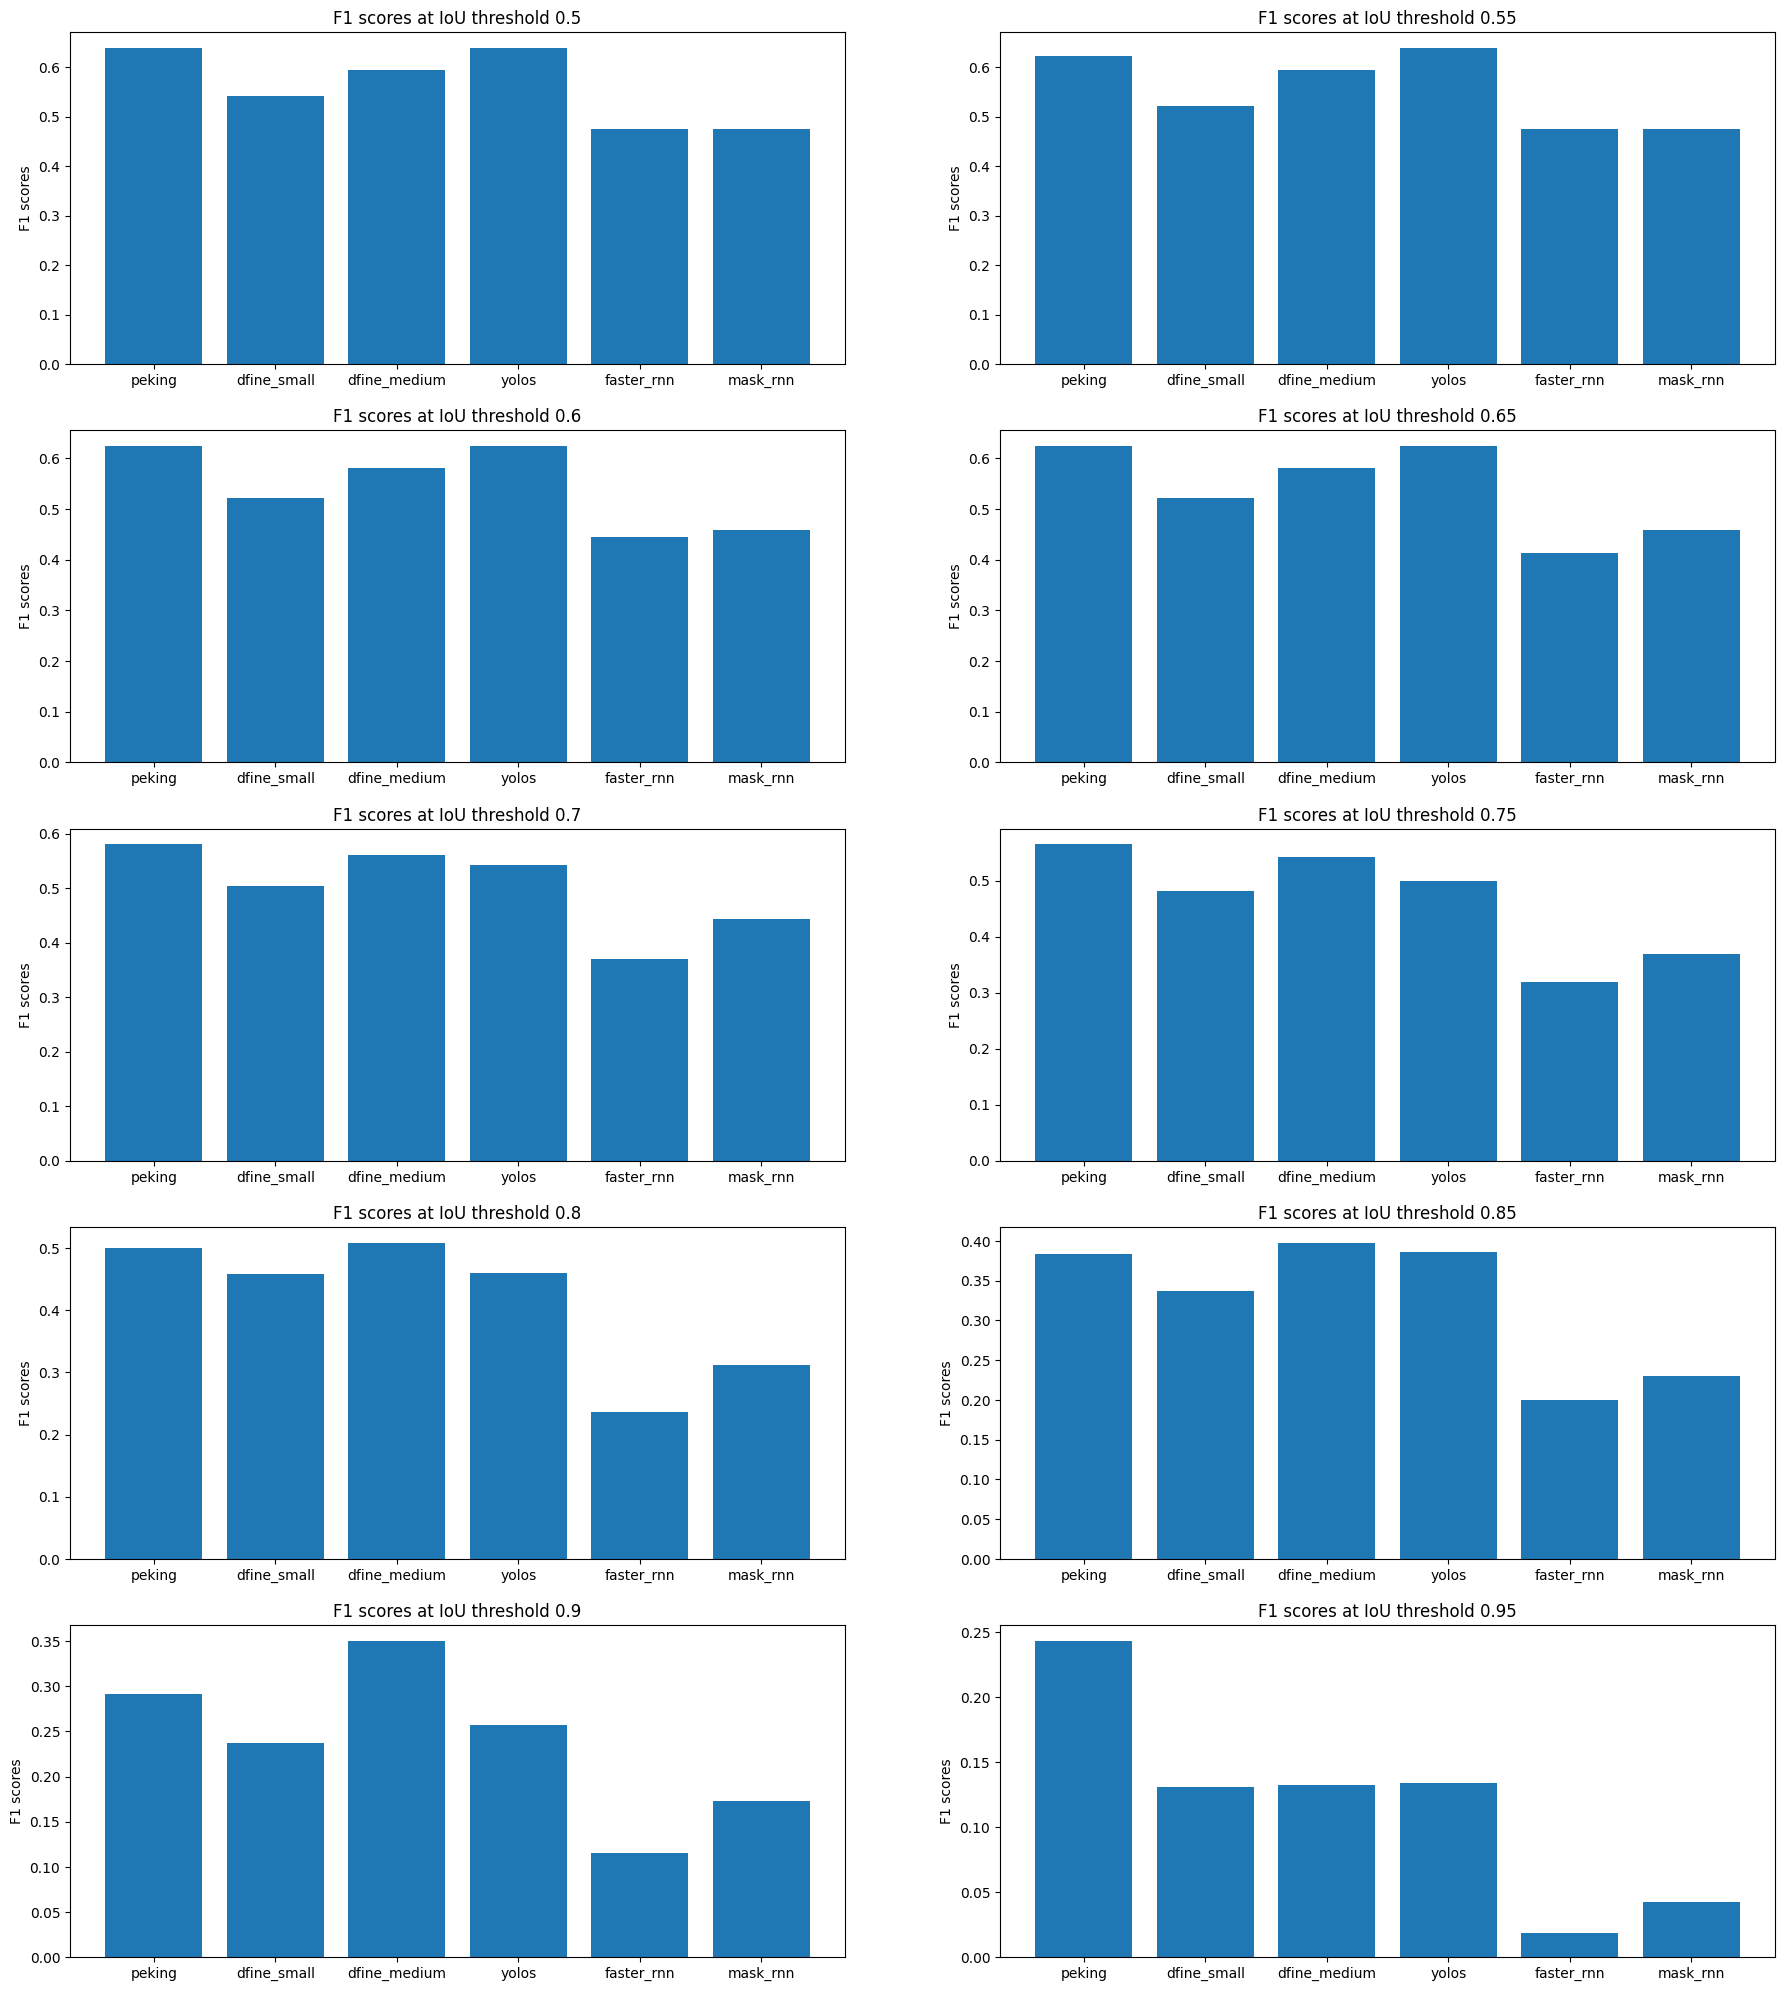

In [ ]:
# Visualize results per threshold
import matplotlib.pyplot as plt

num_plots = len(next(iter(results.values())))

fig, axes = plt.subplots(num_plots//2, 2, figsize=(6*2 + 10, 3*num_plots//2 + 10))
axes = axes.flatten()

for i in range(num_plots):
  values_at_i = [results[k][i] for k in model_names]
  axes[i].bar(model_names, values_at_i)
  axes[i].set_title(f'F1 scores at IoU threshold {iou_thresholds[i]}')
  axes[i].set_ylabel('F1 scores')

In [ ]:
# Look at per-class precision values for selected model

coco_dt = coco_gt.loadRes('/content/peking_model_results.json')
from pycocotools.cocoeval import COCOeval

coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
coco_eval.evaluate()    # Run per-image evaluation
coco_eval.accumulate()  # Accumulate results
coco_eval.summarize()   # Display summary metrics (AP, AR)

Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=18.85s).
Accumulating evaluation results...
DONE (t=3.14s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.002
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.002
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.002
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.002
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.002
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.002
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.002
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.002
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=10

In [ ]:
# 1. Get IDs of annotations specifically belonging to this image
ann_ids = coco_gt.getAnnIds()

# 2. Load only those specific annotations
annotations = coco_gt.loadAnns(ann_ids)

# 3. View the details
results = [{'id': ann['id'], 'category_id': ann['category_id'], 'bbox': ann['bbox']} for ann in annotations]

precisions = coco_eval.eval['precision']
cat_ids = coco_eval.params.catIds

ids = [res['category_id'] for res in results]

precision_results = []

for i, catId in enumerate(cat_ids):
  if catId in ids:
    category_precision = precisions[:, :, i, 0, 2]

    if np.any(category_precision > -1):
      mean_ap = np.mean(category_precision[category_precision > -1])
      cat_name = [cat for cat in categories if cat['id'] == catId][0]['name']
      precision_results.append({
          'category_name' : cat_name,
          'mean_val': mean_ap,
      })
      print(f"Category {catId} ({cat_name}): {mean_ap:.3f}")

Category 1 (person): 0.016
Category 2 (bicycle): 0.009
Category 3 (car): 0.016
Category 4 (motorcycle): 0.014
Category 5 (airplane): 0.006
Category 6 (bus): 0.023
Category 7 (train): 0.017
Category 8 (truck): 0.002
Category 9 (boat): 0.015
Category 10 (traffic light): 0.008
Category 11 (fire hydrant): 0.000
Category 13 (stop sign): 0.000
Category 14 (parking meter): 0.000
Category 15 (bench): 0.000
Category 16 (bird): 0.000
Category 17 (cat): 0.000
Category 18 (dog): 0.001
Category 19 (horse): 0.000
Category 20 (sheep): 0.000
Category 21 (cow): 0.000
Category 22 (elephant): 0.000
Category 23 (bear): 0.000
Category 24 (zebra): 0.000
Category 25 (giraffe): 0.000
Category 27 (backpack): 0.000
Category 28 (umbrella): 0.000
Category 31 (handbag): 0.003
Category 32 (tie): 0.000
Category 33 (suitcase): 0.000
Category 34 (frisbee): 0.000
Category 35 (skis): 0.000
Category 36 (snowboard): 0.000
Category 37 (sports ball): 0.000
Category 38 (kite): 0.000
Category 39 (baseball bat): 0.000
Category

# Fine tuning model
## Disease
Code for finetuning obtained from: https://huggingface.co/learn/cookbook/en/fine_tuning_detr_custom_dataset

In [ ]:
!pip install torch pillow transformers pycocotools datasets torchvision torchmetrics

In [ ]:
!unzip /content/Plantdoc.zip

In [ ]:
!mv /content/PlantDoc.v1-resize-416x416.coco/test/_annotations.coco.json /content/PlantDoc.v1-resize-416x416.coco

In [ ]:
!mv /content/PlantDoc.v1-resize-416x416.coco/train/_annotations.coco.json /content/PlantDoc.v1-resize-416x416.coco

In [ ]:
from pycocotools.coco import COCO
import numpy as np
import torch
import requests
from PIL import Image
from transformers import RTDetrForObjectDetection, RTDetrImageProcessor

coco_gt = COCO('/content/PlantDoc.v1-resize-416x416.coco/_train_annotations.coco.json')

In [ ]:
import numpy as np
from PIL import Image, ImageDraw

ann_ids = coco_gt.getAnnIds()
annotations = coco_gt.loadAnns(ann_ids)
cat_ids = sorted(list(coco_gt.getCatIds()))
categories = coco_gt.loadCats(cat_ids)
id2label = {cat['id']: cat['name'] for cat in categories}
label2id = {v: k for k, v in id2label.items()}
imgIds = coco_gt.getImgIds()

In [ ]:
# Convert to expected image format
def xywh_to_xyxy(box):
  x, y, w, h = box
  return [x, y, x + w, y + h]

In [ ]:
# Convert COCO json to huggingface dataset format
# Abdel, R (2024). Upload COCO Into Huggingface (Version 1.0) [Source Code]. Available at:
# https://www.kaggle.com/code/abdelrahmanhamdi/upload-coco-into-huggingface#Prepare-Images-Folder-To-Create-Dataset

!mkdir detection_dataset

import csv
import os
import numpy as np
from PIL import Image
import json

with open("/content/detection_dataset/metadata.csv", "w") as file:
  writer = csv.writer(file)
  writer.writerow(['file_name' ,'image_id', 'image', 'width', 'height', 'objects'])

  for Image_ID in imgIds:
    img = coco_gt.loadImgs(Image_ID)[0]
    TargetIMG = Image.open(os.path.join('/content/PlantDoc.v1-resize-416x416.coco/train/', img['file_name']))
    output_path = os.path.join('/content/detection_dataset/', f'{Image_ID}.jpg')
    TargetIMG.save(output_path)

    # Find all the annotations that have have the image_id and create an object
    # We'll ignore bbox_id
    objects = {
      'category': [],
      'bbox': [],
      'area': [],
    }

    for annotation in annotations:
      if annotation['image_id'] == Image_ID:
        objects['category'].append(annotation['category_id'])
        objects['bbox'].append(xywh_to_xyxy(annotation['bbox']))
        objects['area'].append(annotation['area'])

    writer.writerow([f'{Image_ID}.jpg', Image_ID, output_path, img['width'], img['height'], json.dumps(objects)])

In [ ]:
!mkdir val

# Create testing dataset
coco_dt = COCO('/content/PlantDoc.v1-resize-416x416.coco/_val_annotations.coco.json')
imgIds = coco_dt.getImgIds() # Corrected: get imgIds from coco_dt instead of coco_gt

with open("/content/val/metadata.csv", "w") as file:
  writer = csv.writer(file)
  writer.writerow(['file_name' ,'image_id', 'image', 'width', 'height', 'objects'])

  for Image_ID in imgIds:
    img = coco_dt.loadImgs(Image_ID)[0]
    TargetIMG = Image.open(os.path.join('/content/PlantDoc.v1-resize-416x416.coco/test/', img['file_name']))
    output_path = os.path.join('/content/val/', f'{Image_ID}.jpg')
    TargetIMG.save(output_path)

    # Find all the annotations that have have the image_id and create an object
    # We'll ignore bbox_id
    objects = {
      'category': [],
      'bbox': [],
      'area': [],
    }

    for annotation in annotations:
      if annotation['image_id'] == Image_ID:
        objects['category'].append(annotation['category_id'])
        objects['bbox'].append(xywh_to_xyxy(annotation['bbox']))
        objects['area'].append(annotation['area'])

    writer.writerow([f'{Image_ID}.jpg', Image_ID, output_path, img['width'], img['height'], json.dumps(objects)])

In [ ]:
from datasets import load_dataset

train_dataset = load_dataset("imagefolder", data_dir="/content/detection_dataset/", drop_labels=True)['train']
test_dataset = load_dataset("imagefolder", data_dir="/content/val/", drop_labels=True)['train']

In [ ]:
from datasets import Image
import json
# Convert the 'objects' string to a dictionary using map
train_dataset = train_dataset.map(lambda x: {"objects": json.loads(x["objects"])})
test_dataset = test_dataset.map(lambda x: {"objects": json.loads(x["objects"])})

# Cast the 'image' path column to the Image feature
train_dataset = train_dataset.cast_column("image", Image())
test_dataset = test_dataset.cast_column("image", Image())

In [ ]:
from datasets import Dataset

def filter_invalid_bboxes(example):
    valid_bboxes = []
    valid_categories = []
    valid_areas = []

    for i, bbox in enumerate(example['objects']['bbox']):
        x_min, y_min, x_max, y_max = bbox[:4]
        if x_min < x_max and y_min < y_max:

            valid_bboxes.append(bbox)
            valid_categories.append(example['objects']['category'][i])
            valid_areas.append(example['objects']['area'][i])
        else:
            print(f"Image with invalid bbox: {example['image_id']} Invalid bbox detected and discarded: {bbox} - bbox_id: {example['objects']['bbox_id'][i]} - category: {example['objects']['category'][i]}")

    example['objects']['bbox'] = valid_bboxes
    example['objects']['category'] = valid_categories
    example['objects']['area'] = valid_areas

    return example

train_dataset = train_dataset.map(filter_invalid_bboxes)
test_dataset = test_dataset.map(filter_invalid_bboxes)

In [ ]:
category_examples = {}
for example in train_dataset:
  for category in example['objects']['category']:
    if id2label[category] not in category_examples:
      category_examples[id2label[category]] = 1
    else:
      category_examples[id2label[category]] += 1

In [ ]:
import albumentations as A

train_transform = A.Compose(
    [
        A.LongestMaxSize(500),
        A.PadIfNeeded(500, 500, border_mode=0, value=(0, 0, 0)),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.5),
        A.Rotate(limit=10, p=0.5),
        A.RandomScale(scale_limit=0.2, p=0.5),
        A.GaussianBlur(p=0.5),
        A.GaussNoise(p=0.5),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True
    ),
)

val_transform = A.Compose(
    [
        A.LongestMaxSize(500),
        A.PadIfNeeded(500, 500, border_mode=0, value=(0, 0, 0)),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True
    ),
)

In [ ]:
from transformers import RTDetrForObjectDetection, RTDetrImageProcessor

# Initialize image processor
image_processor = RTDetrImageProcessor.from_pretrained("PekingU/rtdetr_r101vd_coco_o365")

In [ ]:
def formatted_anns(image_id, category, area, bbox):
    annotations = []
    for i in range(0, len(category)):
        new_ann = {
            "image_id": image_id,
            "category_id": category[i],
            "isCrowd": 0,
            "area": area[i],
            "bbox": list(bbox[i]),
        }
        annotations.append(new_ann)

    return annotations

def convert_voc_to_coco(bbox):
    xmin, ymin, xmax, ymax = bbox
    width = xmax - xmin
    height = ymax - ymin
    return [xmin, ymin, width, height]

def transform_aug_ann(examples, transform):
    image_ids = examples["image_id"]
    images, bboxes, area, categories = [], [], [], []
    for image, objects in zip(examples["image"], examples["objects"]):
        image = np.array(image.convert("RGB"))[:, :, ::-1]
        out = transform(image=image, bboxes=objects["bbox"], category=objects["category"])

        area.append(objects["area"])
        images.append(out["image"])

        # Convert to COCO format
        converted_bboxes = [convert_voc_to_coco(bbox) for bbox in out["bboxes"]]
        bboxes.append(converted_bboxes)

        categories.append(out["category"])

    targets = [
        {"image_id": id_, "annotations": formatted_anns(id_, cat_, ar_, box_)}
        for id_, cat_, ar_, box_ in zip(image_ids, categories, area, bboxes)
    ]

    return image_processor(images=images, annotations=targets, return_tensors="pt")

def transform_train(examples):
    return transform_aug_ann(examples, transform=train_transform)

def transform_val(examples):
    return transform_aug_ann(examples, transform=val_transform)


train_dataset_transformed = train_dataset.with_transform(transform_train)
test_dataset_transformed = test_dataset.with_transform(transform_val)

In [ ]:
model = RTDetrForObjectDetection.from_pretrained("PekingU/rtdetr_r101vd_coco_o365",
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,)

In [ ]:
output_dir = "fine-tuned-results"

In [ ]:
from transformers import TrainingArguments
from transformers import Trainer

import torch
# Define the training arguments

training_args = TrainingArguments(
    output_dir=output_dir,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    dataloader_num_workers=0,
    num_train_epochs=3,
    # max_steps=10000,
    fp16=True,
    save_steps=100,
    logging_steps=200,
    learning_rate=1e-5,
    weight_decay=1e-4,
    save_total_limit=2,
    remove_unused_columns=False,
    eval_steps=500,
    eval_strategy = "steps",
    report_to="none",
    push_to_hub=False,
    batch_eval_metrics=False
)

In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torch.nn.functional import softmax

def denormalize_boxes(boxes, width, height):
    boxes = boxes.clone()
    boxes[:, 0] *= width  # xmin
    boxes[:, 1] *= height  # ymin
    boxes[:, 2] *= width  # xmax
    boxes[:, 3] *= height  # ymax
    return boxes

# No global batch_metrics needed anymore
def compute_metrics(eval_pred):
    # eval_pred now contains predictions and labels for the WHOLE evaluation set
    (loss_dict, scores, pred_boxes, last_hidden_state, encoder_last_hidden_state), labels = eval_pred

    image_sizes = []
    target = []
    for label in labels:
        image_sizes.append(label['orig_size'])
        width, height = label['orig_size']
        denormalized_boxes = denormalize_boxes(label["boxes"], width, height)
        target.append(
            {
                "boxes": denormalized_boxes,
                "labels": label["class_labels"],
            }
        )

    predictions = []
    # Loop through the entire gathered dataset
    for score, box, target_sizes in zip(scores, pred_boxes, image_sizes):
        pred_scores = score[:, :-1]  # Exclude the no-object class
        pred_scores = softmax(pred_scores, dim=-1)
        width, height = target_sizes
        denorm_boxes = denormalize_boxes(box, width, height) # Use local var name to avoid shadowing pred_boxes
        pred_labels = torch.argmax(pred_scores, dim=-1)

        pred_scores_for_labels = torch.gather(pred_scores, 1, pred_labels.unsqueeze(-1)).squeeze(-1)
        predictions.append(
            {
                "boxes": denorm_boxes,
                "scores": pred_scores_for_labels,
                "labels": pred_labels,
            }
        )

    # Initialize and compute in one go
    metric = MeanAveragePrecision(box_format='xywh', class_metrics=True)
    metric.update(preds=predictions, target=target)
    metrics = metric.compute()

    # Format metrics
    classes = metrics.pop("classes")
    map_per_class = metrics.pop("map_per_class")
    mar_100_per_class = metrics.pop("mar_100_per_class")

    for class_id, class_map, class_mar in zip(classes, map_per_class, mar_100_per_class):
        class_name = id2label[class_id.item()] if id2label is not None else class_id.item()
        metrics[f"map_{class_name}"] = class_map
        metrics[f"mar_100_{class_name}"] = class_mar

    # Round metrics for cleaner output
    metrics = {k: round(v.item(), 4) for k, v in metrics.items()}

    return metrics

In [ ]:
def collate_fn(batch):
    pixel_values = [item["pixel_values"] for item in batch]
    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    labels = [item["labels"] for item in batch]

    batch = {}
    batch["pixel_values"] = encoding["pixel_values"]
    batch["pixel_mask"] = encoding["pixel_mask"]
    batch["labels"] = labels

    return batch

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    train_dataset=train_dataset_transformed,
    eval_dataset=test_dataset_transformed,
    tokenizer=image_processor,
    compute_metrics=compute_metrics
)

trainer.train()

In [ ]:
import joblib
joblib.dump(model, "plant_pest_model.joblib")

In [ ]:
import joblib
joblib.dump(model, "plant_disease_model.joblib")

# Pest

In [ ]:
pest_annotations = {}

pest_annotations['info'] = {
    "year": "2019",
    "version": "1",
    "description": "IP102: A Large-Scale Benchmark Dataset for Insect Pest Recognition",
    "contributor": "Xiaoping Wu and Chi Zhan and Yukun Lai and Ming-Ming Cheng and Jufeng Yang",
    "date_created": "2019-06-09"
}

pest_annotations['licenses'] = [{
    'id': 1,
    'url': 'https://creativecommons.org/licenses/by/4.0/deed.en',
    'name': 'CC BY 4.0'
}]

pest_annotations['images'] = []
pest_annotations['annotations'] = []

pest_annotations['categories'] = [
    {'id': 0, 'name': 'rice leaf roller', 'supercategory': 'pest'},
    {'id': 1, 'name': 'rice leaf caterpillar', 'supercategory': 'pest'},
    {'id': 2, 'name': 'paddy stem maggot', 'supercategory': 'pest'},
    {'id': 3, 'name': 'asiatic rice borer', 'supercategory': 'pest'},
    {'id': 4, 'name': 'yellow rice borer', 'supercategory': 'pest'},
    {'id': 5, 'name': 'rice gall midge', 'supercategory': 'pest'},
    {'id': 6, 'name': 'Rice Stemfly', 'supercategory': 'pest'},
    {'id': 7, 'name': 'brown plant hopper', 'supercategory': 'pest'},
    {'id': 8, 'name': 'white backed plant hopper', 'supercategory': 'pest'},
    {'id': 9, 'name': 'small brown plant hopper', 'supercategory': 'pest'},
    {'id': 10, 'name': 'rice water weevil', 'supercategory': 'pest'},
    {'id': 11, 'name': 'rice leafhopper', 'supercategory': 'pest'},
    {'id': 12, 'name': 'grain spreader thrips', 'supercategory': 'pest'},
    {'id': 13, 'name': 'rice shell pest', 'supercategory': 'pest'},
    {'id': 14, 'name': 'grub', 'supercategory': 'pest'},
    {'id': 15, 'name': 'mole cricket', 'supercategory': 'pest'},
    {'id': 16, 'name': 'wireworm', 'supercategory': 'pest'},
    {'id': 17, 'name': 'white margined moth', 'supercategory': 'pest'},
    {'id': 18, 'name': 'black cutworm', 'supercategory': 'pest'},
    {'id': 19, 'name': 'large cutworm', 'supercategory': 'pest'},
    {'id': 20, 'name': 'yellow cutworm', 'supercategory': 'pest'},
    {'id': 21, 'name': 'red spider', 'supercategory': 'pest'},
    {'id': 22, 'name': 'corn borer', 'supercategory': 'pest'},
    {'id': 23, 'name': 'army worm', 'supercategory': 'pest'},
    {'id': 24, 'name': 'aphids', 'supercategory': 'pest'},
    {'id': 25, 'name': 'Potosiabre vitarsis', 'supercategory': 'pest'},
    {'id': 26, 'name': 'peach borer', 'supercategory': 'pest'},
    {'id': 27, 'name': 'english grain aphid', 'supercategory': 'pest'},
    {'id': 28, 'name': 'green bug', 'supercategory': 'pest'},
    {'id': 29, 'name': 'bird cherry-oataphid', 'supercategory': 'pest'},
    {'id': 30, 'name': 'wheat blossom midge', 'supercategory': 'pest'},
    {'id': 31, 'name': 'penthaleus major', 'supercategory': 'pest'},
    {'id': 32, 'name': 'longlegged spider mite', 'supercategory': 'pest'},
    {'id': 33, 'name': 'wheat phloeothrips', 'supercategory': 'pest'},
    {'id': 34, 'name': 'wheat sawfly', 'supercategory': 'pest'},
    {'id': 35, 'name': 'cerodonta denticornis', 'supercategory': 'pest'},
    {'id': 36, 'name': 'beet fly', 'supercategory': 'pest'},
    {'id': 37, 'name': 'flea beetle', 'supercategory': 'pest'},
    {'id': 38, 'name': 'cabbage army worm', 'supercategory': 'pest'},
    {'id': 39, 'name': 'beet army worm', 'supercategory': 'pest'},
    {'id': 40, 'name': 'Beet spot flies', 'supercategory': 'pest'},
    {'id': 41, 'name': 'meadow moth', 'supercategory': 'pest'},
    {'id': 42, 'name': 'beet weevil', 'supercategory': 'pest'},
    {'id': 43, 'name': 'sericaorient alismots chulsky', 'supercategory': 'pest'},
    {'id': 44, 'name': 'alfalfa weevil', 'supercategory': 'pest'},
    {'id': 45, 'name': 'flax budworm', 'supercategory': 'pest'},
    {'id': 46, 'name': 'alfalfa plant bug', 'supercategory': 'pest'},
    {'id': 47, 'name': 'tarnished plant bug', 'supercategory': 'pest'},
    {'id': 48, 'name': 'Locustoidea', 'supercategory': 'pest'},
    {'id': 49, 'name': 'lytta polita', 'supercategory': 'pest'},
    {'id': 50, 'name': 'legume blister beetle', 'supercategory': 'pest'},
    {'id': 51, 'name': 'blister beetle', 'supercategory': 'pest'},
    {'id': 52, 'name': 'therioaphis maculata Buckton', 'supercategory': 'pest'},
    {'id': 53, 'name': 'odontothrips loti', 'supercategory': 'pest'},
    {'id': 54, 'name': 'Thrips', 'supercategory': 'pest'},
    {'id': 55, 'name': 'alfalfa seed chalcid', 'supercategory': 'pest'},
    {'id': 56, 'name': 'Pieris canidia', 'supercategory': 'pest'},
    {'id': 57, 'name': 'Apolygus lucorum', 'supercategory': 'pest'},
    {'id': 58, 'name': 'Limacodidae', 'supercategory': 'pest'},
    {'id': 59, 'name': 'Viteus vitifoliae', 'supercategory': 'pest'},
    {'id': 60, 'name': 'Colomerus vitis', 'supercategory': 'pest'},
    {'id': 61, 'name': 'Brevipoalpus lewisi McGregor', 'supercategory': 'pest'},
    {'id': 62, 'name': 'oides decempunctata', 'supercategory': 'pest'},
    {'id': 63, 'name': 'Polyphagotars onemus latus', 'supercategory': 'pest'},
    {'id': 64, 'name': 'Pseudococcus comstocki Kuwana', 'supercategory': 'pest'},
    {'id': 65, 'name': 'parathrene regalis', 'supercategory': 'pest'},
    {'id': 66, 'name': 'Ampelophaga', 'supercategory': 'pest'},
    {'id': 67, 'name': 'Lycorma delicatula', 'supercategory': 'pest'},
    {'id': 68, 'name': 'Xylotrechus', 'supercategory': 'pest'},
    {'id': 69, 'name': 'Cicadella viridis', 'supercategory': 'pest'},
    {'id': 70, 'name': 'Miridae', 'supercategory': 'pest'},
    {'id': 71, 'name': 'Trialeurodes vaporariorum', 'supercategory': 'pest'},
    {'id': 72, 'name': 'Erythroneura apicalis', 'supercategory': 'pest'},
    {'id': 73, 'name': 'Papilio xuthus', 'supercategory': 'pest'},
    {'id': 74, 'name': 'Panonchus citri McGregor', 'supercategory': 'pest'},
    {'id': 75, 'name': 'Phyllocoptes oleiverus ashmead', 'supercategory': 'pest'},
    {'id': 76, 'name': 'Icerya purchasi Maskell', 'supercategory': 'pest'},
    {'id': 77, 'name': 'Unaspis yanonensis', 'supercategory': 'pest'},
    {'id': 78, 'name': 'Ceroplastes rubens', 'supercategory': 'pest'},
    {'id': 79, 'name': 'Chrysomphalus aonidum', 'supercategory': 'pest'},
    {'id': 80, 'name': 'Parlatoria zizyphus Lucus', 'supercategory': 'pest'},
    {'id': 81, 'name': 'Nipaecoccus vastalor', 'supercategory': 'pest'},
    {'id': 82, 'name': 'Aleurocanthus spiniferus', 'supercategory': 'pest'},
    {'id': 83, 'name': 'Tetradacus c Bactrocera minax', 'supercategory': 'pest'},
    {'id': 84, 'name': 'Dacus dorsalis(Hendel)', 'supercategory': 'pest'},
    {'id': 85, 'name': 'Bactrocera tsuneonis', 'supercategory': 'pest'},
    {'id': 86, 'name': 'Prodenia litura', 'supercategory': 'pest'},
    {'id': 87, 'name': 'Adristyrannus', 'supercategory': 'pest'},
    {'id': 88, 'name': 'Phyllocnistis citrella Stainton', 'supercategory': 'pest'},
    {'id': 89, 'name': 'Toxoptera citricidus', 'supercategory': 'pest'},
    {'id': 90, 'name': 'Toxoptera aurantii', 'supercategory': 'pest'},
    {'id': 91, 'name': 'Aphis citricola Vander Goot', 'supercategory': 'pest'},
    {'id': 92, 'name': 'Scirtothrips dorsalis Hood', 'supercategory': 'pest'},
    {'id': 93, 'name': 'Dasineura sp', 'supercategory': 'pest'},
    {'id': 94, 'name': 'Lawana imitata Melichar', 'supercategory': 'pest'},
    {'id': 95, 'name': 'Salurnis marginella Guerr', 'supercategory': 'pest'},
    {'id': 96, 'name': 'Deporaus marginatus Pascoe', 'supercategory': 'pest'},
    {'id': 97, 'name': 'Chlumetia transversa', 'supercategory': 'pest'},
    {'id': 98, 'name': 'Mango flat beak leafhopper', 'supercategory': 'pest'},
    {'id': 99, 'name': 'Rhytidodera bowrinii white', 'supercategory': 'pest'},
    {'id': 100, 'name': 'Sternochetus frigidus', 'supercategory': 'pest'},
    {'id': 101, 'name': 'Cicadellidae', 'supercategory': 'pest'}
]

In [ ]:
!unzip /content/Annotations.zip

In [ ]:
from pathlib import Path
import xml.etree.ElementTree as ET
image_id = 0
annotation_id = 0

# Create annotations for potassium
dir_path = Path("/content/Annotations")
for file_path in dir_path.iterdir():
    if file_path.is_file() and file_path.suffix == '.xml':  # Only process XML files
        try:
            # Check if file is empty
            if file_path.stat().st_size == 0:
                print(f"Skipping empty file: {file_path.name}")
                continue

            tree = ET.parse(file_path)
            root = tree.getroot()
            size = root.find('size')
            objects = root.findall('object')

            # Image data
            file_name = f'/content/JPEGImages/{root.find('filename').text}' if root.find('filename').text[-4:] == '.jpg' else f'/content/JPEGImages/{root.find('filename').text}.jpg'
            width = int(size.find('width').text)
            height = int(size.find('height').text)

            pest_annotations['images'].append({
                'id': image_id,
                'license': 1,
                'file_name': file_name,
                'height': height,
                'width': width,
                'date_captured': '2019-06-09T07:33:07+00:00'
            })

            # Annotation data
            for object_element in objects:
                # Convert XML category ID (1-102) to 0-indexed (0-101)
                category_id = int(object_element.find('name').text)
                bbox = object_element.find('bndbox')

                xmin = int(bbox.find('xmin').text)
                xmax = int(bbox.find('xmax').text)
                ymin = int(bbox.find('ymin').text)
                ymax = int(bbox.find('ymax').text)

                area = (xmax - xmin) * (ymax - ymin)

                pest_annotations['annotations'].append({
                    'id': annotation_id,
                    'image_id': image_id,
                    'category_id': category_id, # Use the 0-indexed category_id
                    'bbox': [xmin, ymin, xmax, ymax],
                    'area': area,
                    'segmentation': [],
                    'iscrowd': 0
                })
                annotation_id += 1

            image_id += 1
        except ET.ParseError as e:
            print(f"Error parsing XML file {file_path.name}: {e}")

In [ ]:
import json

with open("_annotations.coco.json", "w") as file:
  json.dump(pest_annotations, file, indent=4)

In [ ]:
from pycocotools.coco import COCO
import numpy as np
import torch
import requests
from PIL import Image
from transformers import RTDetrForObjectDetection, RTDetrImageProcessor

coco_gt = COCO('/content/_annotations.coco.json')

In [ ]:
import numpy as np
from PIL import Image, ImageDraw

ann_ids = coco_gt.getAnnIds()
annotations = coco_gt.loadAnns(ann_ids)
cat_ids = sorted(list(coco_gt.getCatIds()))
categories = coco_gt.loadCats(cat_ids)
id2label = {cat['id']: cat['name'] for cat in categories}
label2id = {v: k for k, v in id2label.items()}
imgIds = coco_gt.getImgIds()

In [ ]:
!unzip /content/JPEGImages.zip

The same process as that used for disease detection was used after this therefore the above cells were simply rerun